# Relatório Operacional de Pré-Decolagem

Este notebook apresenta a análise de dados de telemetria para apoio à tomada de decisão em um cenário de pré-decolagem.

## Observação metodológica
Os dados utilizados neste projeto são simulados e foram organizados com base em parâmetros plausíveis de um cenário pré-operacional de decolagem. O objetivo é demonstrar a aplicação de técnicas computacionais de análise, classificação de risco e apoio à decisão, e não reproduzir com exatidão um sistema real de engenharia aeroespacial.

## Importação das bibliotecas
Nesta etapa, são importadas as bibliotecas necessárias para leitura, tratamento e visualização dos dados, além das funções auxiliares definidas no arquivo `utils.py`.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.utils import (
    classificar_risco,
    calcular_autonomia,
    identificar_anomalia,
    sugerir_acao,
    motivo_risco,
    calcular_prontidao,
    parecer_final
)

## Leitura da base de dados
Os dados de telemetria foram armazenados em um arquivo CSV contendo informações operacionais relevantes para a análise pré-decolagem.

In [16]:
df = pd.read_csv("../data/telemetria.csv")
df.head()

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos
0,24,-15,1,92,5.8,OK
1,26,-18,1,85,5.5,OK
2,29,-20,1,70,5.0,OK
3,31,-22,0,60,4.2,ALERTA
4,22,-12,1,40,4.8,OK


## Estrutura e estatísticas descritivas
Nesta etapa, verificamos a estrutura do conjunto de dados, seus tipos de variáveis e algumas estatísticas descritivas iniciais.

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   temperatura_interna     8 non-null      int64  
 1   temperatura_externa     8 non-null      int64  
 2   integridade_estrutural  8 non-null      int64  
 3   nivel_energia           8 non-null      int64  
 4   pressao_tanque          8 non-null      float64
 5   modulos_criticos        8 non-null      str    
dtypes: float64(1), int64(4), str(1)
memory usage: 516.0 bytes


In [18]:
df.describe()

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque
count,8.000000,8.000000,8.00000,8.000000,8.000000
mean,27.250000,-17.375000,0.75000,64.375000,4.937500
std,4.399675,5.012484,0.46291,23.993675,0.696804
min,22.000000,-25.000000,0.00000,25.000000,3.900000
25%,23.750000,-20.500000,0.75000,51.250000,4.500000
50%,27.000000,-17.500000,1.00000,65.000000,4.900000
75%,29.500000,-14.250000,1.00000,85.750000,5.550000
max,35.000000,-10.000000,1.00000,92.000000,5.800000


## Classificação de risco
Nesta etapa, os dados de telemetria são classificados em três níveis de risco: Normal, Atenção e Crítico, com base em regras relacionadas à integridade estrutural, módulos críticos, energia e pressão dos tanques.


In [19]:
df["classificacao_risco"] = df.apply(classificar_risco, axis=1)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos,classificacao_risco
0,24,-15,1,92,5.8,OK,Normal
1,26,-18,1,85,5.5,OK,Normal
2,29,-20,1,70,5.0,OK,Normal
3,31,-22,0,60,4.2,ALERTA,Crítico
4,22,-12,1,40,4.8,OK,Normal
5,35,-25,0,25,3.9,FALHA,Crítico
6,28,-17,1,55,4.6,ALERTA,Atenção
7,23,-10,1,88,5.7,OK,Normal


## Sugestão operacional
Com base na classificação de risco, o sistema gera uma recomendação operacional para apoiar a tomada de decisão no cenário de pré-decolagem.

In [20]:
df["sugestao_risco"] = df["classificacao_risco"].apply(sugerir_acao)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos,classificacao_risco,sugestao_risco
0,24,-15,1,92,5.8,OK,Normal,Operação dentro dos padrões.
1,26,-18,1,85,5.5,OK,Normal,Operação dentro dos padrões.
2,29,-20,1,70,5.0,OK,Normal,Operação dentro dos padrões.
3,31,-22,0,60,4.2,ALERTA,Crítico,Decolagem não recomendada até correção das fal...
4,22,-12,1,40,4.8,OK,Normal,Operação dentro dos padrões.
5,35,-25,0,25,3.9,FALHA,Crítico,Decolagem não recomendada até correção das fal...
6,28,-17,1,55,4.6,ALERTA,Atenção,Revisar parâmetros antes da decolagem.
7,23,-10,1,88,5.7,OK,Normal,Operação dentro dos padrões.


## Análise energética
A autonomia estimada foi calculada com base no nível de carga atual, considerando capacidade total, consumo previsto na decolagem e perdas energéticas.

In [21]:
df["autonomia_estimada_horas"] = df["nivel_energia"].apply(calcular_autonomia)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos,classificacao_risco,sugestao_risco,autonomia_estimada_horas
0,24,-15,1,92,5.8,OK,Normal,Operação dentro dos padrões.,6.7
1,26,-18,1,85,5.5,OK,Normal,Operação dentro dos padrões.,6.0
2,29,-20,1,70,5.0,OK,Normal,Operação dentro dos padrões.,4.5
3,31,-22,0,60,4.2,ALERTA,Crítico,Decolagem não recomendada até correção das fal...,3.5
4,22,-12,1,40,4.8,OK,Normal,Operação dentro dos padrões.,1.5
5,35,-25,0,25,3.9,FALHA,Crítico,Decolagem não recomendada até correção das fal...,0.0
6,28,-17,1,55,4.6,ALERTA,Atenção,Revisar parâmetros antes da decolagem.,3.0
7,23,-10,1,88,5.7,OK,Normal,Operação dentro dos padrões.,6.3


## Identificação de anomalias
Nesta etapa, o sistema identifica possíveis anomalias operacionais, como temperatura elevada, falha estrutural, baixa pressão, energia crítica e falhas em módulos críticos.

In [22]:
df["anomalias"] = df.apply(identificar_anomalia, axis=1)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos,classificacao_risco,sugestao_risco,autonomia_estimada_horas,anomalias
0,24,-15,1,92,5.8,OK,Normal,Operação dentro dos padrões.,6.7,Nenhuma
1,26,-18,1,85,5.5,OK,Normal,Operação dentro dos padrões.,6.0,Nenhuma
2,29,-20,1,70,5.0,OK,Normal,Operação dentro dos padrões.,4.5,Nenhuma
3,31,-22,0,60,4.2,ALERTA,Crítico,Decolagem não recomendada até correção das fal...,3.5,"Temperatura interna alta, Falha estrutural, Pr..."
4,22,-12,1,40,4.8,OK,Normal,Operação dentro dos padrões.,1.5,Nenhuma
5,35,-25,0,25,3.9,FALHA,Crítico,Decolagem não recomendada até correção das fal...,0.0,"Temperatura interna alta, Falha estrutural, Pr..."
6,28,-17,1,55,4.6,ALERTA,Atenção,Revisar parâmetros antes da decolagem.,3.0,Nenhuma
7,23,-10,1,88,5.7,OK,Normal,Operação dentro dos padrões.,6.3,Nenhuma


## Motivo do risco
Além da classificação, o sistema também registra os fatores que justificam cada nível de risco identificado, tornando a análise mais explicável e interpretável.

In [23]:
df["motivo_risco"] = df.apply(motivo_risco, axis=1)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos,classificacao_risco,sugestao_risco,autonomia_estimada_horas,anomalias,motivo_risco
0,24,-15,1,92,5.8,OK,Normal,Operação dentro dos padrões.,6.7,Nenhuma,Nenhum fator crítico identificado
1,26,-18,1,85,5.5,OK,Normal,Operação dentro dos padrões.,6.0,Nenhuma,Nenhum fator crítico identificado
2,29,-20,1,70,5.0,OK,Normal,Operação dentro dos padrões.,4.5,Nenhuma,Nenhum fator crítico identificado
3,31,-22,0,60,4.2,ALERTA,Crítico,Decolagem não recomendada até correção das fal...,3.5,"Temperatura interna alta, Falha estrutural, Pr...","Integridade estrutural comprometida, Pressão d..."
4,22,-12,1,40,4.8,OK,Normal,Operação dentro dos padrões.,1.5,Nenhuma,Nenhum fator crítico identificado
5,35,-25,0,25,3.9,FALHA,Crítico,Decolagem não recomendada até correção das fal...,0.0,"Temperatura interna alta, Falha estrutural, Pr...","Integridade estrutural comprometida, Falha em ..."
6,28,-17,1,55,4.6,ALERTA,Atenção,Revisar parâmetros antes da decolagem.,3.0,Nenhuma,Nenhum fator crítico identificado
7,23,-10,1,88,5.7,OK,Normal,Operação dentro dos padrões.,6.3,Nenhuma,Nenhum fator crítico identificado


## Índice de prontidão operacional
Foi criado um índice de prontidão operacional em escala de 0 a 100, com o objetivo de resumir as condições gerais do sistema antes da decolagem.

In [24]:
df["indice_prontidao"] = df.apply(calcular_prontidao, axis=1)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos,classificacao_risco,sugestao_risco,autonomia_estimada_horas,anomalias,motivo_risco,indice_prontidao
0,24,-15,1,92,5.8,OK,Normal,Operação dentro dos padrões.,6.7,Nenhuma,Nenhum fator crítico identificado,100
1,26,-18,1,85,5.5,OK,Normal,Operação dentro dos padrões.,6.0,Nenhuma,Nenhum fator crítico identificado,100
2,29,-20,1,70,5.0,OK,Normal,Operação dentro dos padrões.,4.5,Nenhuma,Nenhum fator crítico identificado,100
3,31,-22,0,60,4.2,ALERTA,Crítico,Decolagem não recomendada até correção das fal...,3.5,"Temperatura interna alta, Falha estrutural, Pr...","Integridade estrutural comprometida, Pressão d...",15
4,22,-12,1,40,4.8,OK,Normal,Operação dentro dos padrões.,1.5,Nenhuma,Nenhum fator crítico identificado,90
5,35,-25,0,25,3.9,FALHA,Crítico,Decolagem não recomendada até correção das fal...,0.0,"Temperatura interna alta, Falha estrutural, Pr...","Integridade estrutural comprometida, Falha em ...",0
6,28,-17,1,55,4.6,ALERTA,Atenção,Revisar parâmetros antes da decolagem.,3.0,Nenhuma,Nenhum fator crítico identificado,85
7,23,-10,1,88,5.7,OK,Normal,Operação dentro dos padrões.,6.3,Nenhuma,Nenhum fator crítico identificado,100


## Parecer final
Com base no índice de prontidão, o sistema gera um parecer final sobre a aptidão operacional do sistema.

In [25]:
df["parecer_final"] = df["indice_prontidao"].apply(parecer_final)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos,classificacao_risco,sugestao_risco,autonomia_estimada_horas,anomalias,motivo_risco,indice_prontidao,parecer_final
0,24,-15,1,92,5.8,OK,Normal,Operação dentro dos padrões.,6.7,Nenhuma,Nenhum fator crítico identificado,100,Sistema apto para operação
1,26,-18,1,85,5.5,OK,Normal,Operação dentro dos padrões.,6.0,Nenhuma,Nenhum fator crítico identificado,100,Sistema apto para operação
2,29,-20,1,70,5.0,OK,Normal,Operação dentro dos padrões.,4.5,Nenhuma,Nenhum fator crítico identificado,100,Sistema apto para operação
3,31,-22,0,60,4.2,ALERTA,Crítico,Decolagem não recomendada até correção das fal...,3.5,"Temperatura interna alta, Falha estrutural, Pr...","Integridade estrutural comprometida, Pressão d...",15,Sistema não apto para decolagem
4,22,-12,1,40,4.8,OK,Normal,Operação dentro dos padrões.,1.5,Nenhuma,Nenhum fator crítico identificado,90,Sistema apto para operação
5,35,-25,0,25,3.9,FALHA,Crítico,Decolagem não recomendada até correção das fal...,0.0,"Temperatura interna alta, Falha estrutural, Pr...","Integridade estrutural comprometida, Falha em ...",0,Sistema não apto para decolagem
6,28,-17,1,55,4.6,ALERTA,Atenção,Revisar parâmetros antes da decolagem.,3.0,Nenhuma,Nenhum fator crítico identificado,85,Sistema apto para operação
7,23,-10,1,88,5.7,OK,Normal,Operação dentro dos padrões.,6.3,Nenhuma,Nenhum fator crítico identificado,100,Sistema apto para operação


## Visualização gráfica dos resultados
Nesta etapa, são apresentados gráficos que auxiliam na interpretação dos dados de telemetria, da classificação de risco, da autonomia estimada e do índice de prontidão operacional. Essas visualizações facilitam a identificação de padrões e apoiam a análise do cenário pré-operacional de decolagem.

### Distribuição das classificações de risco
O gráfico a seguir mostra a quantidade de registros classificados em cada nível de risco: Normal, Atenção e Crítico. Essa visualização permite identificar a condição geral do conjunto de dados analisado.

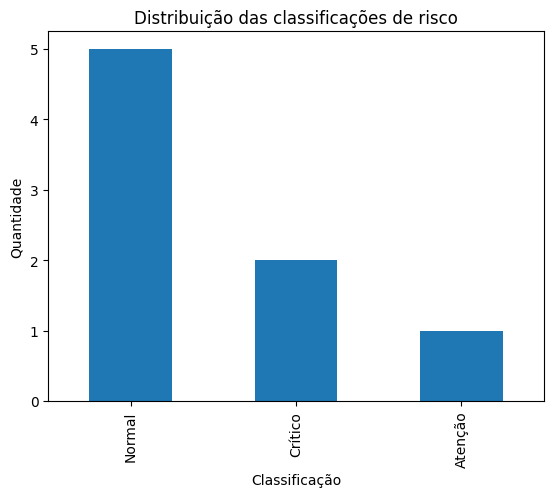

In [26]:
df["classificacao_risco"].value_counts().plot(kind="bar")
plt.title("Distribuição das classificações de risco")
plt.xlabel("Classificação")
plt.ylabel("Quantidade")
plt.show()

### Autonomia estimada por registro
O gráfico abaixo apresenta a autonomia estimada para cada registro da base de dados, considerando o nível de energia disponível, o consumo de decolagem e as perdas energéticas. Essa visualização ajuda a verificar quais cenários apresentam maior limitação energética.

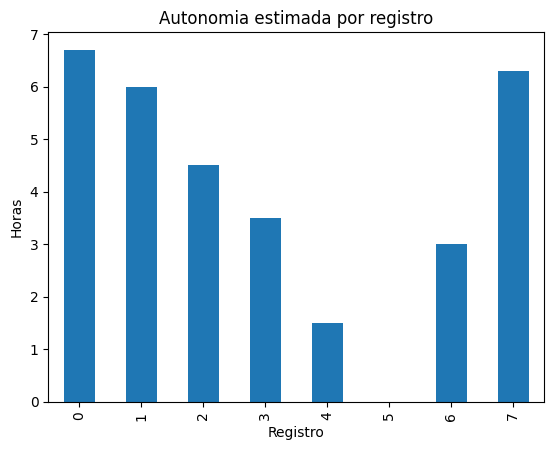

In [27]:
df["autonomia_estimada_horas"].plot(kind="bar")
plt.title("Autonomia estimada por registro")
plt.xlabel("Registro")
plt.ylabel("Horas")
plt.show()

### Índice de prontidão operacional
O gráfico a seguir apresenta o índice de prontidão operacional de cada registro, em uma escala de 0 a 100. Quanto maior o índice, melhores são as condições do sistema para operação no contexto pré-decolagem.

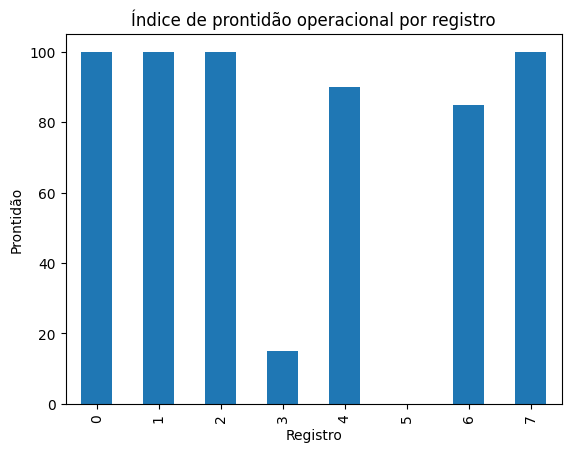

In [28]:
df["indice_prontidao"].plot(kind="bar")
plt.title("Índice de prontidão operacional por registro")
plt.xlabel("Registro")
plt.ylabel("Prontidão")
plt.show()

### Interpretação visual dos resultados
A análise gráfica permite observar a predominância de registros classificados como normais, mas também evidencia a presença de situações de atenção e criticidade. Além disso, os gráficos de autonomia e índice de prontidão ajudam a identificar registros com menor capacidade operacional, reforçando a importância da análise integrada entre energia, integridade estrutural, pressão dos tanques e status dos módulos críticos.

### Resumo quantitativo dos resultados
Além das visualizações gráficas, foi elaborado um resumo quantitativo com indicadores gerais do conjunto de dados, permitindo observar a distribuição das classificações de risco, dos pareceres finais e os valores médios de autonomia e prontidão operacional.

In [29]:
print("Quantidade de registros:", len(df))
print("\nClassificações de risco:")
print(df["classificacao_risco"].value_counts())

print("\nParecer final:")
print(df["parecer_final"].value_counts())

print("\nMédia de autonomia estimada:")
print(df["autonomia_estimada_horas"].mean())

print("\nMédia do índice de prontidão:")
print(df["indice_prontidao"].mean())

Quantidade de registros: 8

Classificações de risco:
classificacao_risco
Normal     5
Crítico    2
Atenção    1
Name: count, dtype: int64

Parecer final:
parecer_final
Sistema apto para operação         6
Sistema não apto para decolagem    2
Name: count, dtype: int64

Média de autonomia estimada:
3.9375

Média do índice de prontidão:
73.75


### Distribuição do parecer final
O gráfico a seguir apresenta a quantidade de registros classificados em cada categoria de parecer final, permitindo visualizar de forma direta a condição geral do sistema em relação à prontidão operacional.

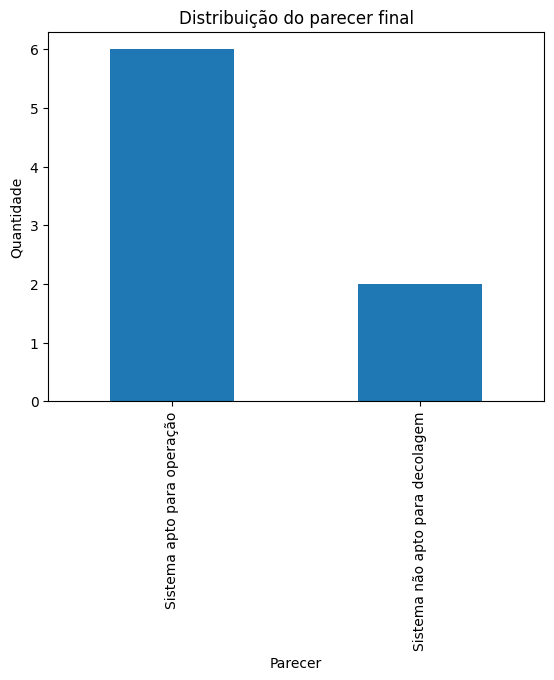

In [30]:
df["parecer_final"].value_counts().plot(kind="bar")
plt.title("Distribuição do parecer final")
plt.xlabel("Parecer")
plt.ylabel("Quantidade")
plt.show()

## Reflexão crítica
O uso de sistemas computacionais e técnicas de inteligência artificial em cenários de pré-decolagem pode aumentar a eficiência da análise e reduzir erros humanos. No entanto, esse uso exige responsabilidade, transparência e validação dos critérios adotados.

Do ponto de vista ético, decisões automatizadas em contextos críticos devem sempre ser supervisionadas, principalmente quando envolvem segurança operacional. Além disso, a exploração espacial e o desenvolvimento tecnológico precisam considerar impactos sociais, custos de implementação e questões de sustentabilidade tecnológica a longo prazo.

## Conclusão
A análise realizada permitiu organizar e interpretar dados de telemetria em um cenário simulado de pré-decolagem. A combinação entre classificação de risco, análise energética, identificação de anomalias e cálculo do índice de prontidão operacional mostrou como ferramentas computacionais podem apoiar decisões em contextos críticos. Os resultados evidenciam que a análise integrada dos parâmetros operacionais contribui para uma avaliação mais clara e segura das condições do sistema.